In [360]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler


In [365]:
train = pd.read_csv("C:\\Users\\paone\\OneDrive\\Desktop\\py\\.ipynb_checkpoints\\train-checkpoint.csv")
public_test = pd.read_csv("C:\\Users\\paone\\OneDrive\\Desktop\\py\\public_test.csv")  ##not used, idk y
private_test = pd.read_csv("C:\\Users\\paone\\OneDrive\\Desktop\\py\\private_test.csv")

print("Train Shape:", train.shape)
#print("Public Test Shape:", public_test.shape)
#print("Private Test Shape:", private_test.shape)

#train.head()
train.columns

Train Shape: (10000, 14)


Index(['User_ID', 'Age', 'Income', 'City_Tier', 'Device_Type',
       'Traffic_Source', 'Pages_Viewed', 'Products_Viewed', 'Time_On_Site',
       'Previous_Purchases', 'Discount_Seen', 'Browser_Version',
       'Campaign_Code', 'Converted'],
      dtype='str')

In [368]:
TARGET = train.iloc[:,-1]
type(TARGET)

pandas.Series

In [369]:
print(train.size)
print(train.shape)
print(train.info())

140000
(10000, 14)
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   User_ID             10000 non-null  int64  
 1   Age                 8520 non-null   float64
 2   Income              9016 non-null   float64
 3   City_Tier           10000 non-null  int64  
 4   Device_Type         10000 non-null  str    
 5   Traffic_Source      10000 non-null  str    
 6   Pages_Viewed        10000 non-null  int64  
 7   Products_Viewed     10000 non-null  int64  
 8   Time_On_Site        8152 non-null   float64
 9   Previous_Purchases  10000 non-null  int64  
 10  Discount_Seen       10000 non-null  int64  
 11  Browser_Version     10000 non-null  int64  
 12  Campaign_Code       10000 non-null  int64  
 13  Converted           10000 non-null  int64  
dtypes: float64(3), int64(9), str(2)
memory usage: 1.2 MB
None


In [370]:
x=train.select_dtypes(include=["str"]).columns.tolist()

In [371]:
print(train[x[0]].value_counts())
print('###')
print(train[x[1]].value_counts())

Device_Type
Mobile     6523
Desktop    2472
Tablet     1005
Name: count, dtype: int64
###
Traffic_Source
Organic         3071
Paid Ads        2544
Social Media    1993
Referral        1456
Email            936
Name: count, dtype: int64


### Encoding

In [372]:
X_train= pd.get_dummies(train, drop_first= True, dtype='int8')
#print(X_train.head())
print(X_train.columns)
print(train.columns)
y_train=X_train.loc[:,'Converted']
X_train.drop(columns= 'Converted', inplace= True)
X_train.info()

X_private= pd.get_dummies(private_test, drop_first= True, dtype='int8')
X_private.info()

Index(['User_ID', 'Age', 'Income', 'City_Tier', 'Pages_Viewed',
       'Products_Viewed', 'Time_On_Site', 'Previous_Purchases',
       'Discount_Seen', 'Browser_Version', 'Campaign_Code', 'Converted',
       'Device_Type_Mobile', 'Device_Type_Tablet', 'Traffic_Source_Organic',
       'Traffic_Source_Paid Ads', 'Traffic_Source_Referral',
       'Traffic_Source_Social Media'],
      dtype='str')
Index(['User_ID', 'Age', 'Income', 'City_Tier', 'Device_Type',
       'Traffic_Source', 'Pages_Viewed', 'Products_Viewed', 'Time_On_Site',
       'Previous_Purchases', 'Discount_Seen', 'Browser_Version',
       'Campaign_Code', 'Converted'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   User_ID                      10000 non-null  int64  
 1   Age                          8520 non-null   float64
 2   Income  

In [373]:
#from plotnine import ggplot, aes, geom_point

### EDA

In [374]:
train.select_dtypes(include=['int8','int64','float64']).isna().sum()

User_ID                  0
Age                   1480
Income                 984
City_Tier                0
Pages_Viewed             0
Products_Viewed          0
Time_On_Site          1848
Previous_Purchases       0
Discount_Seen            0
Browser_Version          0
Campaign_Code            0
Converted                0
dtype: int64

Age
25.0    205
28.0    195
52.0    193
58.0    192
29.0    191
46.0    189
45.0    189
48.0    188
49.0    188
37.0    188
33.0    187
47.0    186
65.0    185
19.0    183
21.0    183
62.0    182
50.0    182
51.0    181
32.0    180
39.0    180
36.0    180
35.0    179
41.0    179
40.0    178
24.0    177
61.0    176
31.0    176
27.0    176
59.0    175
38.0    174
44.0    174
34.0    173
43.0    172
63.0    172
55.0    171
57.0    169
30.0    169
26.0    167
56.0    167
20.0    167
18.0    165
64.0    164
60.0    164
42.0    163
22.0    163
53.0    163
23.0    162
54.0    158
Name: count, dtype: int64


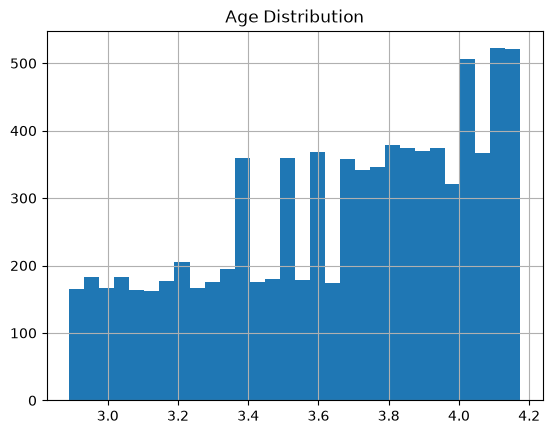

In [375]:
import matplotlib.pyplot as plt
import numpy as np

print(X_train['Age'].value_counts())

np.log(X_train['Age']).hist(bins=30)
plt.title("Age Distribution")
plt.show()

#left skewed distribution; should impute NA val with median

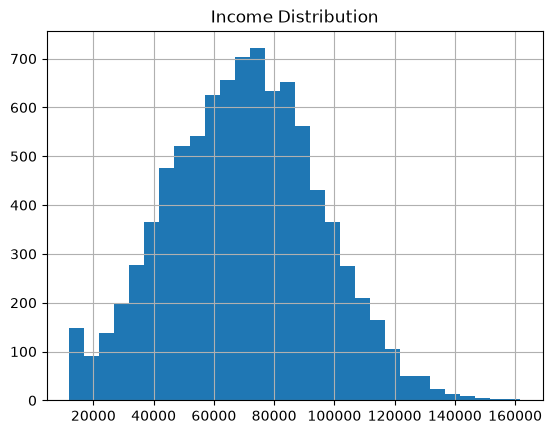

In [376]:
X_train['Income'].hist(bins=30)
plt.title("Income Distribution") ##impute with mean
plt.show()

In [377]:
print("missing val:",train['Time_On_Site'].isna().sum())

#print( X_train['Time_On_Site'].value_counts())
print(X_train['Time_On_Site'].value_counts()[lambda x: (x>10)]) ##22 val
print(X_train['Time_On_Site'].value_counts()[lambda x: (x > 5) & (x<10)]) ##421 val
print(X_train['Time_On_Site'].value_counts()[lambda x: (x < 5)]) ##1695 val
print(X_train['Time_On_Site'].nunique())
print(max(X_train['Time_On_Site']))
print(min(X_train['Time_On_Site']))

missing val: 1848
Time_On_Site
6.73     15
13.13    14
7.72     13
8.10     12
10.83    12
9.07     12
11.38    12
7.61     11
10.64    11
4.92     11
11.62    11
12.19    11
10.91    11
7.33     11
7.65     11
6.91     11
13.14    11
11.99    11
7.50     11
8.64     11
9.79     11
9.58     11
Name: count, dtype: int64
Time_On_Site
12.61    9
9.93     9
8.85     9
9.34     9
5.55     9
        ..
8.40     6
15.93    6
10.92    6
9.52     6
5.34     6
Name: count, Length: 421, dtype: int64
Time_On_Site
16.92    4
16.59    4
15.23    4
20.26    4
12.80    4
        ..
38.11    1
3.29     1
21.96    1
24.48    1
22.22    1
Name: count, Length: 1695, dtype: int64
2381
607.39
0.8


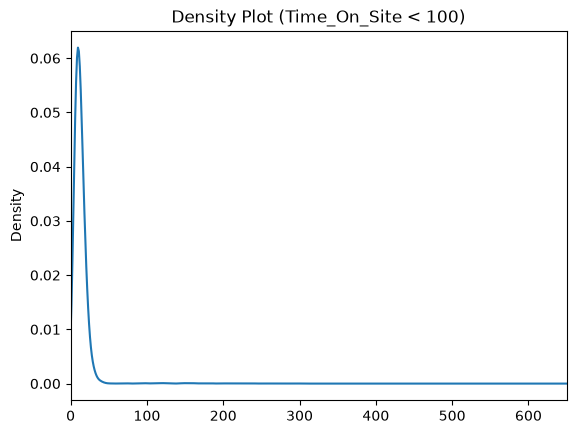

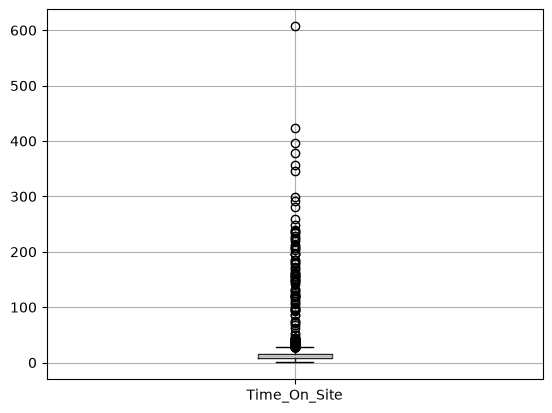

In [378]:
X_train['Time_On_Site'].dropna().plot(kind='density')
plt.title("Density Plot (Time_On_Site < 100)")
plt.xlim(0,650)
plt.show() ##right skewed

X_train[['Time_On_Site']].boxplot()
plt.show()

In [379]:
X_train[['Age','Income','Time_On_Site']].sample(5)

,Age,Income,Time_On_Site
8267,43.0,89712.700320,22.40
2548,35.0,NaN,NaN
9468,45.0,29387.436264,NaN
3771,50.0,49178.958716,5.98
6298,27.0,53625.708611,8.25


## Handling Missing Data

In [380]:
median_imputer = SimpleImputer(strategy='median')

X_train[['Time_On_Site', 'Age']] = median_imputer.fit_transform(
    X_train[['Time_On_Site', 'Age']]
)

X_private[['Time_On_Site', 'Age']] = median_imputer.transform(
    X_private[['Time_On_Site', 'Age']]
)


mean_imputer = SimpleImputer(strategy='mean')

X_train[['Income']] = mean_imputer.fit_transform(
    X_train[['Income']]
)

X_private[['Income']] = mean_imputer.transform(
    X_private[['Income']]
)

print(X_train.isna().sum())
print(X_private.isna().sum())

User_ID                        0
Age                            0
Income                         0
City_Tier                      0
Pages_Viewed                   0
Products_Viewed                0
Time_On_Site                   0
Previous_Purchases             0
Discount_Seen                  0
Browser_Version                0
Campaign_Code                  0
Device_Type_Mobile             0
Device_Type_Tablet             0
Traffic_Source_Organic         0
Traffic_Source_Paid Ads        0
Traffic_Source_Referral        0
Traffic_Source_Social Media    0
dtype: int64
User_ID                        0
Age                            0
Income                         0
City_Tier                      0
Pages_Viewed                   0
Products_Viewed                0
Time_On_Site                   0
Previous_Purchases             0
Discount_Seen                  0
Browser_Version                0
Campaign_Code                  0
Device_Type_Mobile             0
Device_Type_Tablet            

In [381]:
X_train[['Age','Income','Time_On_Site']].sample(5)

,Age,Income,Time_On_Site
8086,27.0,48763.152002,21.32
6082,41.0,92555.885888,11.23
8923,59.0,94522.146399,11.07
579,55.0,55872.498042,13.77
9832,41.0,61670.701021,16.66


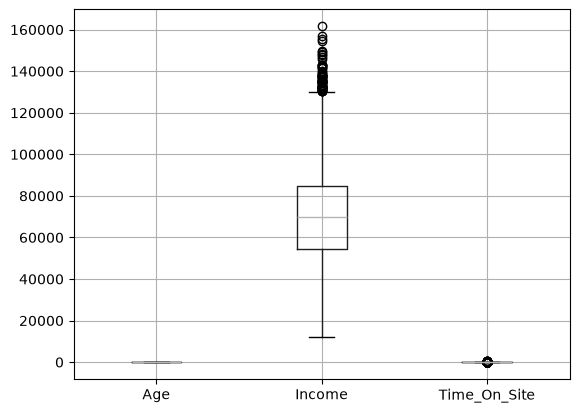

In [382]:
X_train[['Age','Income','Time_On_Site']].boxplot()
plt.show()

## age: no outliers
## time on site: many outliers
## income: avg outliers


In [383]:
X_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   User_ID                      10000 non-null  int64  
 1   Age                          10000 non-null  float64
 2   Income                       10000 non-null  float64
 3   City_Tier                    10000 non-null  int64  
 4   Pages_Viewed                 10000 non-null  int64  
 5   Products_Viewed              10000 non-null  int64  
 6   Time_On_Site                 10000 non-null  float64
 7   Previous_Purchases           10000 non-null  int64  
 8   Discount_Seen                10000 non-null  int64  
 9   Browser_Version              10000 non-null  int64  
 10  Campaign_Code                10000 non-null  int64  
 11  Device_Type_Mobile           10000 non-null  int8   
 12  Device_Type_Tablet           10000 non-null  int8   
 13  Traffic_Source_Organic      

### Standard Scaling

In [384]:
# Scale features to zero mean and unit variance
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.iloc[:,1:]) ##fit and transfrom in one step
X_private_scaled = scaler.transform(X_private.iloc[:,1:])

In [385]:
print(type(X_train_scaled))

<class 'numpy.ndarray'>


### Logistic Regression

In [386]:
model = LogisticRegression(max_iter=1000, class_weight='balanced') ##without assigning balanced weights, the minority class would be under-represented
model.fit(X_train_scaled, y_train)

print("Model trained successfully!")
print("Training Accuracy: {:.4f}".format(model.score(X_train_scaled, y_train)))


Model trained successfully!
Training Accuracy: 0.6750


In [387]:
predictions = model.predict(X_private_scaled)

submission = pd.DataFrame({
    "User_ID": private_test["User_ID"],
    "Converted": predictions
})

submission.to_csv("C:\\Users\\paone\\OneDrive\\Desktop\\py\\submission.csv", index=False)

print("submission.csv created successfully!")
submission.head()


submission.csv created successfully!


,User_ID,Converted
0,103001,0
1,103002,0
2,103003,0
3,103004,1
4,103005,0


In [388]:
from sklearn.metrics import f1_score
# Predictions
y_pred = model.predict(X_train_scaled)

# F1 Score
f1 = f1_score(y_train, y_pred)
print("F1 Score: {:.4f}".format(f1))

F1 Score: 0.5672
